### 障碍期权（Barrier Options）
障碍期权的收益取决于标的在一定时间区段是否跨过一定阈值。  
敲出期权（Knock-out option）：标的跨过障碍价位后失效。  
敲入期权（Knock-in option）：标的跨过障碍价位后生效。  
本笔记以向下敲出欧式看涨期权为例(down-and-out European call option)

大纲：
1. 输入参数和网格构建
2. Heston模型PDE公式
3. 边界条件
4. 偏导
5. 系数矩阵
6. 交替方向隐式方法（Alternative Direction Implicit, ADI）Douglas方案
7. 代码封装和实验
8. 希腊字母
9. 后续考虑

In [ ]:
%pip install numpy scipy pandas matplotlib

<a id="step1"></a>
### 输入参数和网格构建
1. 期权参数
2. 计算域
3. 网格分辨率与拉伸

In [1]:
# input parameters for Knock-out call option
S0 = 100 #Initial stock price
K = 100 #Strike price
B = 80 #Barrier level
R = 0 #Rebate
T = 1 #Time to maturity
r = 0.02 #Risk-free rate
kappa = 2.0 #Mean reversion rate
theta = 0.04 #Long-term variance
sigma = 0.5 #Volatility of variance
rho = -0.7 #Correlation between the stock price and its variance

In [2]:
# Computational domain parameters
S_min = 0
S_max = 400
v_min = 0
v_max = 0.5

In [3]:
Ns = 200 #Number of stock price steps
Nv = 50 #Number of variance steps
Nt = 100 #Number of time steps

"""
c(Asset Clustering): Controls the density of points around the strike K.
A smaller c leads to more clustering of asset price steps around the K.
start with c = K/5, and adjust based on the observed convergence of the option price.
"""
c = 20 #Asset clustering factor. 

"""
d(Variance Clustering): Controls the density of points near v = 0.
Volatility is highly convex near v = 0, and the PDE degenerate there.
A smaller d leads to more clustering of variance steps near v = 0.
start with d = v_max/10, and adjust based on the observed convergence of the option price.
"""
d = 0.05 #Variance clustering factor.

""" 
In 2D Alternative Direction Implicit (ADI) schemes, 
the theta parameter controls the implicitness of the time-stepping method.
Setting theta>=0.5 is strictly required to garantee the stability of the ADI scheme.
"""
theta_ADI = 0.5 #ADI scheme parameter. Common choices are 0.5 (Crank-Nicolson) or 1.0 (fully implicit).


双曲正弦拉伸

In [4]:
import numpy as np

def create_nonuniform_asset_grid(S_min, S_max, Ns, K, c):
    """
    Create a non-uniform grid for the asset price with clustering around strike K.
    Use tanh stretching to cluster points around K
    """
    # Create stretched coordinates in [-1, 1]
    xi = np.linspace(-1, 1, Ns)

    # Larger alpha => stronger clustering around K
    alpha = c

    # Map xi in [-1, 1] to eta in [-1, 1]
    eta = np.sinh(alpha * xi) / np.sinh(alpha)
    
    # Picewise linear mapping to cluster around K
    S_grid = np.where(
        eta <= 0,
        K + (K - S_min) * eta,      # Left side: [S_min, K]
        K + (S_max - K) * eta       # Right side: [K, S_max]
    )

    return np.sort(S_grid)

def create_nonuniform_variance_grid(v_min, v_max, Nv, d):
    """
    Create a non-uniform grid for the variance with clustering near v=0.
    """
    # Create stretched coordinates in [0, 1]
    xi = np.linspace(0, 1, Nv)

    # Choose alpha so that d acts like a near-zero clustering scale
    alpha = np.arcsinh((v_max - v_min) / d)
    
    v_grid = v_min + d * np.sinh(alpha * xi)
    
    return v_grid

# Generate the non-uniform grids
S_grid = create_nonuniform_asset_grid(S_min, S_max, Ns, K, c)
v_grid = create_nonuniform_variance_grid(v_min, v_max, Nv, d)

Note: you may need to restart the kernel to use updated packages.


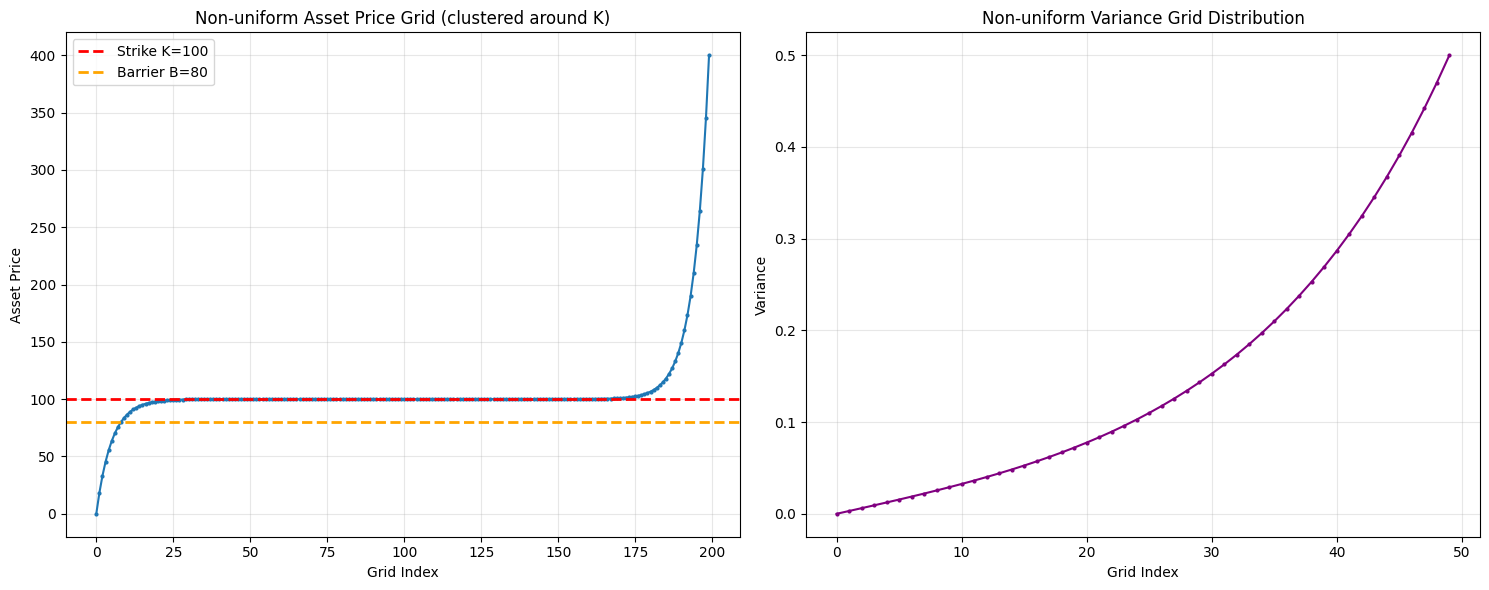

In [5]:
import matplotlib.pyplot as plt

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Asset price grid
ax1.plot(range(len(S_grid)), S_grid, 'o-', markersize=2)
ax1.axhline(K, color='r', linestyle='--', linewidth=2, label=f'Strike K={K}')
ax1.axhline(B, color='orange', linestyle='--', linewidth=2, label=f'Barrier B={B}')
ax1.set_xlabel('Grid Index')
ax1.set_ylabel('Asset Price')
ax1.set_title('Non-uniform Asset Price Grid (clustered around K)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Variance grid distribution
ax2.plot(range(len(v_grid)), v_grid, 'o-', markersize=2, color='purple')
ax2.set_xlabel('Grid Index')
ax2.set_ylabel('Variance')
ax2.set_title('Non-uniform Variance Grid Distribution')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Heston模型PDE公式
$$
\frac{\partial U}{\partial t}
+ \frac{1}{2}vS^2 \frac{\partial^2 U}{\partial S^2}
+ \rho \sigma v S \frac{\partial^2 U}{\partial S \partial v}
+ \frac{1}{2}\sigma^2 v \frac{\partial^2 U}{\partial v^2}
+ rS \frac{\partial U}{\partial S}
+ \kappa^*(\theta^* - v)\frac{\partial U}{\partial v}
- rU = 0
$$

### 边界条件
1. S <= B, knock-out
2. S = S_max
3. v = 0, 退化PDE
4. v = v_max，期权价格将不再受v影响

In [6]:
# State-value matrix: rows for S, columns for v
U = np.zeros((Ns, Nv))

# Terminal payoff for a call option: max(S-K, 0)
U[:, :] = np.maximum(S_grid[:, None] - K, 0.0)
U[S_grid <= B, :] = 0.0

In [7]:
def apply_boundary_conditions(U, S_grid, K, B, r, tau):
    """
    Apply boundary conditions for the barrier option.
    - For S <= B (below the barrier), the option value is 0.
    - For S = S_max, the option value approaches S-K.
    - For v = 0 (zero variance), the PDE degenerate.
    - For v = v_max (high variance), we can use a large value or extrapolation.
    """
    # Apply barrier condition
    U[S_grid <= B, :] = 0.0
    
    # Apply boundary condition for S_max
    U[-1, :] = S_max - K * np.exp(-r * tau)  # Discounted payoff at S_max
    
    # Apply high variance condition
    U[:, -1] = U[:, -2]  # Neumann condition (zero gradient) at v_max

    # Re-enforce barrier condition after applying other boundaries
    U[S_grid <= B, :] = 0.0
    
    return U

### 偏导


In [8]:
def first_derivative_matrix(x):
    """
    Create a first derivative matrix using central differences on a non-uniform grid.
    For interior points, use central differences.
    For boundaries, use forward/backward differences.
    """
    N = len(x)
    D = np.zeros((N, N))
    
    # Interior points: central differences
    for i in range(1, N - 1):
        # Central difference in the interior
        hm = x[i] - x[i-1]  # Backward step
        hp = x[i+1] - x[i]  # Forward step

        D[i, i-1] = -hp / (hm * (hm + hp))
        D[i, i] = (hp - hm) / (hm * hp)
        D[i, i+1] = hm / (hp * (hm + hp))
    
    # Forward difference at the left boundary
    D[0, 0] = -1 / (x[1] - x[0])
    D[0, 1] = 1 / (x[1] - x[0])
    
    # Backward difference at the right boundary
    D[N-1, N-2] = -1 / (x[N-1] - x[N-2])
    D[N-1, N-1] = 1 / (x[N-1] - x[N-2])
    
    return D

def second_derivative_matrix(x):
    """
    Second derivative matrix using central differences on a non-uniform grid.
    For interior points, use central differences.
    For boundaries, treat them later on PDE.
    """
    N = len(x)
    D2 = np.zeros((N, N))

    for i in range(1, N - 1):
        hm = x[i] - x[i-1]  # Backward step
        hp = x[i+1] - x[i]  # Forward step

        D2[i, i-1] = 2 / (hm * (hm + hp))
        D2[i, i] = -2 / (hm * hp)
        D2[i, i+1] = 2 / (hp * (hm + hp))

    return D2

D_S = first_derivative_matrix(S_grid)
D_SS = second_derivative_matrix(S_grid)
D_v = first_derivative_matrix(v_grid)
D_vv = second_derivative_matrix(v_grid)

U_S = D_S @ U
U_SS = D_SS @ U
U_v = U @ D_v.T
U_vv = U @ D_vv.T
U_Sv = D_S @ U @ D_v.T

print(D_S.shape, D_SS.shape, D_v.shape, D_vv.shape)
print(U_S.shape, U_SS.shape, U_v.shape, U_vv.shape, U_Sv.shape)

(200, 200) (200, 200) (50, 50) (50, 50)
(200, 50) (200, 50) (200, 50) (200, 50) (200, 50)


### 系数矩阵
$A = A0 + A1 + A2$
1. $A0 = \rho \sigma v S \frac{\partial^2 U}{\partial S \partial v}$，混合偏导部分
2. $A1 = \frac{1}{2}vS^2 \frac{\partial^2 U}{\partial S^2} + rS \frac{\partial U}{\partial S} - \frac{1}{2}rU$，S方向部分
3. $A2 = \frac{1}{2}\sigma^2 v \frac{\partial^2 U}{\partial v^2} + \kappa^*(\theta^* - v)\frac{\partial U}{\partial v} - \frac{1}{2}rU$，v方向部分

In [9]:
from scipy.sparse import diags, eye, kron, csr_matrix

I_S = eye(Ns, format='csr')
I_v = eye(Nv, format='csr')

S_diag = diags(S_grid, format='csr')
S2_diag = diags(S_grid**2, format='csr')
v_diag = diags(v_grid, format='csr')
kv_diag = diags(kappa * (theta - v_grid), format='csr')

# Mixed derivative part:
A0 = rho * sigma * kron(v_diag @ D_v, S_diag @D_S, format='csr')

# S-direction part:
A1 = (
    0.5 * kron(v_diag, S2_diag @ D_SS, format='csr')
    + r * kron(I_v, S_diag @ D_S, format='csr')
    - 0.5 * r * eye(Ns * Nv, format='csr')
)

# v-direction part:
A2 = (
    0.5 * sigma**2 * kron(v_diag @ D_vv, I_S, format='csr')
    + kron(kv_diag @ D_v, I_S, format='csr')
    - 0.5 * r * eye(Ns * Nv, format='csr')
)

A = A0 + A1 + A2

Note: you may need to restart the kernel to use updated packages.


### 交替方向隐式方法（Alternative Direction Implicit, ADI）Douglas方案

In [10]:
import numpy as np
from scipy.sparse import eye, csr_matrix
from scipy.sparse.linalg import splu

# --- basic setup ---
dt = T / Nt
theta_adi = theta_ADI
theta_heston = theta

# vectorization convention: Fortran order
u = U.flatten(order='F')  # Flatten in Fortran order (column-major)

I = eye(Ns * Nv, format='csr')

# Implicit matrices for ADI substeps
M1 = (I - theta_adi * dt * A1).tocsc()
M2 = (I - theta_adi * dt * A2).tocsc()

# Pre-factorize the matrices for efficient solves
lu_M1 = splu(M1)
lu_M2 = splu(M2)

dv0 = v_grid[1] - v_grid[0]
alpha_v0 = kappa * theta_heston / dv0

I_S_sparse = eye(Ns, format='csr')
D_S_sparse = csr_matrix(D_S)

# Redeced PDE operator at v=0:
# U_tau = r S U_S + alpha U1 - (r + alpha) U0
L_v0 = (r * (S_diag @ D_S_sparse) - (alpha_v0 + r) * I_S_sparse).tocsc() 

# Implicit matrix for the v=0 boundary solve
M_v0 = (I_S_sparse - dt * L_v0).tocsc()
lu_v0 = splu(M_v0)

def apply_boundary_conditions_matrix(U_mat, S_grid, v_grid, K, B, r, tau):
    """
    Boundary conditions for the PDE of down-and-out call:
    tau = time remaining to maturity in backward stepping.
    """
    S_max = S_grid[-1]

    # Knock-out barrier
    U_mat[S_grid <= B, :] = 0.0

    # S = 0
    U_mat[0, :] = 0.0

    # S = S_max: option value approaches S-K
    U_mat[-1, :] = S_max - K * np.exp(-r * tau)  # Discounted payoff at S_max

    # v = v_max, simple Neumann approximation (zero gradient)
    U_mat[:, -1] = U_mat[:, -2]

    # v = 0, PDE degenerate, handeled separately

    # re-enforce barrier
    U_mat[S_grid <= B, :] = 0.0

    return U_mat

def enforce_v0_boundary_european(U_mat, S_grid, K, r, tau, kappa, theta, dt):
    """
    For v=0, the PDE degenerate
    Stable implicit treatment of the degenerate Heston PDE at v=0
    for a European down-and-out call
    """
    U0_old = U_mat[:, 0].copy()
    U1 = U_mat[:, 1].copy()

    rhs = U0_old + dt * alpha_v0 * U1
    U0_new = lu_v0.solve(rhs)

    U_mat[:, 0] = U0_new

    # Re-impose boundary conditions at v=0
    U_mat[S_grid <= B, 0] = 0.0
    U_mat[0, 0] = 0.0
    U_mat[-1, 0] = S_grid[-1] - K * np.exp(-r * tau)

    return U_mat

def douglas_adi_step(u_n, dt, theta_adi, A, A1, A2, lu_M1, lu_M2):
    """
    One Douglas ADI step in pseudo-time tau = T - t
    """
    Y0 = u_n + dt * (A @ u_n)

    rhs1 = Y0 - theta_adi * dt * (A1 @ u_n)
    Y1 = lu_M1.solve(rhs1)

    rhs2 = Y1 - theta_adi * dt * (A2 @ u_n)
    Y2 = lu_M2.solve(rhs2)

    return Y2

# Start from terminal condition
U_work = U.copy()
u = U_work.flatten(order='F')

for n in range(Nt):
    tau_np1 = T - (n + 1) * dt

    # ADI step in vector form
    u = douglas_adi_step(u, dt, theta_adi, A, A1, A2, lu_M1, lu_M2)

    # Back to matrix form
    U_work = u.reshape((Ns, Nv), order='F')

    # Apply standard European barrier/boundary conditions
    U_work = apply_boundary_conditions_matrix(U_work, S_grid, v_grid, K, B, r, tau_np1)

    # Apply v=0 reduced-PDE correction
    U_work = enforce_v0_boundary_european(
        U_work, S_grid, K, r, tau_np1, kappa, theta_heston, dt
    )

    # Re-vectorize
    u = U_work.flatten(order='F')
    print(
        n,
        np.nanmin(U_work),
        np.nanmax(U_work),
        np.any(np.isnan(U_work)),
        np.any(np.isinf(U_work))
    )


U0 = U_work
print("ADI stepping finished.")

i = np.argmin(np.abs(S_grid - S0))
j = np.argmin(np.abs(v_grid - theta_heston))  # Assuming initial variance is long-term variance
price = U0[i,j]
print("option price at S0:", S0, "volatility:", np.sqrt(theta_heston), "is: ",price)


0 0.0 301.9605267353303 False False
1 -9.422643022087411e-10 301.94091687975714 False False
2 -1.1146138229116393e-07 301.9213031018207 False False
3 -1.2055581988777842e-06 301.90168540073637 False False
4 -5.679833614317513e-06 301.8820637757194 False False
5 -1.813096367754449e-05 301.862438225985 False False
6 -4.15450902224269e-05 301.8428087507481 False False
7 -7.846111080952145e-05 301.82317534922356 False False
8 -0.00012874409421749895 301.803538020626 False False
9 -0.00018821611825798395 301.7838967641699 False False
10 -0.00025517260220173923 301.76425157906976 False False
11 -0.0003338461562134705 301.7446024645396 False False
12 -0.00040589036607465204 301.7249494197936 False False
13 -0.0004792073606722506 301.7052924440454 False False
14 -0.0005554581766660868 301.68563153650905 False False
15 -0.000607745267049298 301.66596669639785 False False
16 -0.0006828911703275544 301.6462979229254 False False
17 -0.0007336711342429677 301.6266252153048 False False
18 -0.0007817

### 代码封装和实验

In [11]:
import importlib
import barrier_heston_adi as bha

importlib.reload(bha)

params = bha.KnockOutCallParams(S0=100, K=100, B=80, Ns=200, Nv=50, Nt=100, debug=True)
result = bha.price_european_down_and_out_call_heston_adi(params)
print(result["price"])



0 0.0 301.9605267353303 False False
1 -9.422643022087411e-10 301.94091687975714 False False
2 -1.1146138229116393e-07 301.9213031018207 False False
3 -1.2055581988777842e-06 301.90168540073637 False False
4 -5.679833614317513e-06 301.8820637757194 False False
5 -1.813096367754449e-05 301.862438225985 False False
6 -4.15450902224269e-05 301.8428087507481 False False
7 -7.846111080952145e-05 301.82317534922356 False False
8 -0.00012874409421749895 301.803538020626 False False
9 -0.00018821611825798395 301.7838967641699 False False
10 -0.00025517260220173923 301.76425157906976 False False
11 -0.0003338461562134705 301.7446024645396 False False
12 -0.00040589036607465204 301.7249494197936 False False
13 -0.0004792073606722506 301.7052924440454 False False
14 -0.0005554581766660868 301.68563153650905 False False
15 -0.000607745267049298 301.66596669639785 False False
16 -0.0006828911703275544 301.6462979229254 False False
17 -0.0007336711342429677 301.6266252153048 False False
18 -0.0007817

In [12]:
base_params = dict(
    S0=100,
    K=100,
    B=80,
    R=0,
    T=1,
    r=0.02,
    kappa=2.0,
    theta=0.04,
    sigma=0.5,
    rho=-0.7,
    S_min=0,
    S_max=400,
    v_min=0,
    v_max=0.5,
    Ns=200,
    Nv=50,
    Nt=100,
    c=20,
    d=0.05,
    theta_ADI=0.5,
    v0=0.04,
    debug=False,
)


[resolution] run 1/15 finished in 0.501s with price=8.208270056381
[resolution] run 2/15 finished in 0.691s with price=8.319055547254
[resolution] run 3/15 finished in 0.951s with price=8.281496462452
[resolution] run 4/15 finished in 1.254s with price=8.245671093005
[resolution] run 5/15 finished in 1.881s with price=8.211857256362
[resolution] run 6/15 finished in 2.600s with price=8.180001414963
[resolution] run 7/15 finished in 3.424s with price=8.263157366996
[resolution] run 8/15 finished in 5.565s with price=8.233407907172
[resolution] run 9/15 finished in 6.962s with price=8.205714065150
[resolution] run 10/15 finished in 9.476s with price=8.159858676538
[resolution] run 11/15 finished in 19.079s with price=8.159261469012
[resolution] run 12/15 finished in 49.437s with price=8.163857466437
[resolution] run 13/15 finished in 98.244s with price=8.167181671339
[resolution] run 14/15 finished in 212.878s with price=8.141683549225
[resolution] run 15/15 finished in 463.585s with pri

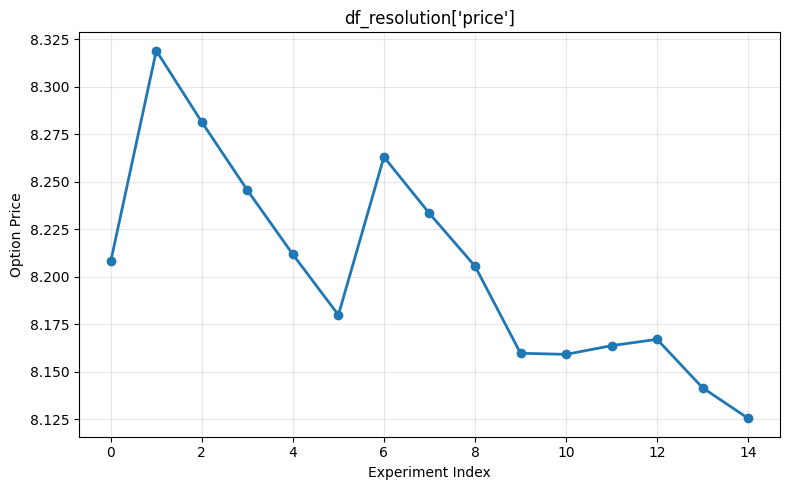

In [13]:
resolution_experiments = [
    {"Ns": 200, "Nv": 80, "Nt": 500},
    {"Ns": 220, "Nv": 90, "Nt": 600},
    {"Ns": 240, "Nv": 100, "Nt": 700},
    {"Ns": 260, "Nv": 110, "Nt": 800},
    {"Ns": 280, "Nv": 120, "Nt": 1000},
    {"Ns": 300, "Nv": 130, "Nt": 1200},
    {"Ns": 320, "Nv": 140, "Nt": 1400},
    {"Ns": 340, "Nv": 160, "Nt": 1600},
    {"Ns": 360, "Nv": 180, "Nt": 1800},
    {"Ns": 400, "Nv": 200, "Nt": 2000},
    {"Ns": 400, "Nv": 200, "Nt": 4000},
    {"Ns": 800, "Nv": 200, "Nt": 4000},
    {"Ns": 1600, "Nv": 200, "Nt": 4000},
    {"Ns": 1600, "Nv": 400, "Nt": 4000},
    {"Ns": 1600, "Nv": 800, "Nt": 4000}
]

df_resolution = bha.run_experiment_grid(base_params, resolution_experiments, "resolution")

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(df_resolution["price"], marker="o", linewidth=2)
plt.xlabel("Experiment Index")
plt.ylabel("Option Price")
plt.title("df_resolution['price']")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


结合收敛与用时，之后的实验使用以下基准参数  
1. $Ns = 400$
2. $Nv = 200$
3. $Nt = 2000$  

下面测试$S$和$v$的参数域

[domain] run 1/12 finished in 9.863s with price=8.151746359954
[domain] run 2/12 finished in 9.656s with price=8.159858676538
[domain] run 3/12 finished in 10.722s with price=8.164904488484
[domain] run 4/12 finished in 10.408s with price=8.170072189789
[domain] run 5/12 finished in 10.087s with price=8.151746457106
[domain] run 6/12 finished in 10.876s with price=8.159858629286
[domain] run 7/12 finished in 10.337s with price=8.164904405480
[domain] run 8/12 finished in 12.271s with price=8.170072306842
[domain] run 9/12 finished in 11.676s with price=8.151746085144
[domain] run 10/12 finished in 10.333s with price=8.159858393308
[domain] run 11/12 finished in 10.413s with price=8.164904104472
[domain] run 12/12 finished in 10.122s with price=8.170071925147


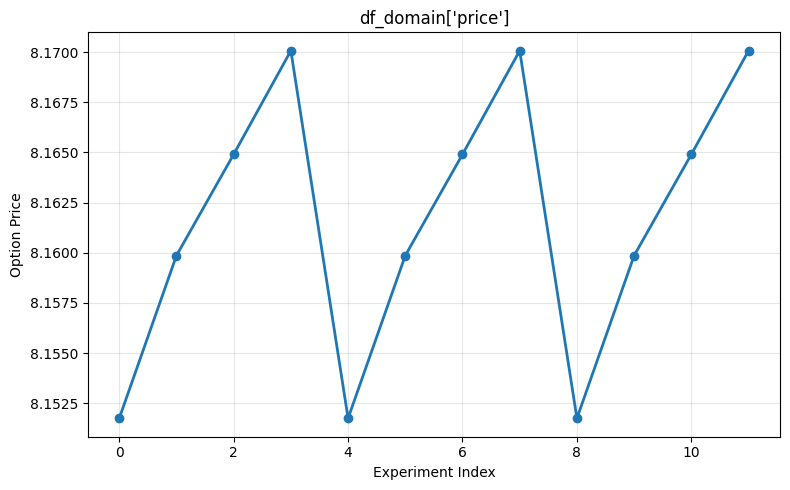

In [14]:
base_params.update({
    "Ns": 400,
    "Nv": 200,
    "Nt": 2000,
})

domain_experiments = [
    {"S_max": 400, "v_max": 0.3},
    {"S_max": 400, "v_max": 0.5},
    {"S_max": 400, "v_max": 0.7},
    {"S_max": 400, "v_max": 1.0},
    {"S_max": 600, "v_max": 0.3},
    {"S_max": 600, "v_max": 0.5},
    {"S_max": 600, "v_max": 0.7},
    {"S_max": 600, "v_max": 1.0},
    {"S_max": 800, "v_max": 0.3},
    {"S_max": 800, "v_max": 0.5},
    {"S_max": 800, "v_max": 0.7},
    {"S_max": 800, "v_max": 1.0},
]

df_domain = bha.run_experiment_grid(base_params, domain_experiments, "domain")

plt.figure(figsize=(8, 5))
plt.plot(df_domain["price"], marker="o", linewidth=2)
plt.xlabel("Experiment Index")
plt.ylabel("Option Price")
plt.title("df_domain['price']")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


$S$在400以上结果已收敛。  
$v$随着其增大，期权价格上升，之后使用0.5，即波动率为70%为默认v_max。  
之后对于ADI解析参数进行测试。

[theta_ADI] run 1/4 finished in 10.174s with price=8.159858676538
[theta_ADI] run 2/4 finished in 10.343s with price=8.160260175806
[theta_ADI] run 3/4 finished in 10.116s with price=8.160514287612
[theta_ADI] run 4/4 finished in 10.223s with price=8.160915131216


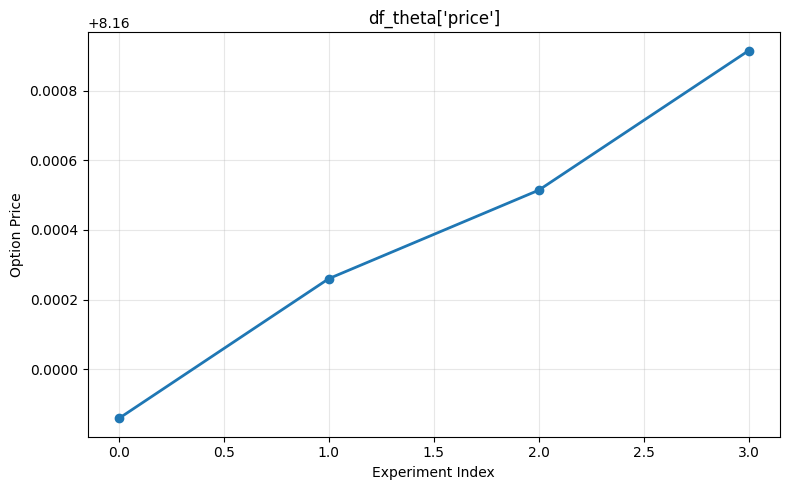

In [15]:
theta_experiments = [
    {"theta_ADI": 0.5},
    {"theta_ADI": 0.6},
    {"theta_ADI": 0.75},
    {"theta_ADI": 1.0},
]

df_theta = bha.run_experiment_grid(base_params, theta_experiments, "theta_ADI")

plt.figure(figsize=(8, 5))
plt.plot(df_theta["price"], marker="o", linewidth=2)
plt.xlabel("Experiment Index")
plt.ylabel("Option Price")
plt.title("df_theta['price']")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

[asset_clustering] run 1/5 finished in 10.265s with price=8.166156993122
[asset_clustering] run 2/5 finished in 9.696s with price=8.163509514086
[asset_clustering] run 3/5 finished in 9.631s with price=8.185529874711
[asset_clustering] run 4/5 finished in 10.349s with price=8.159858676538
[asset_clustering] run 5/5 finished in 10.489s with price=376.114464661606


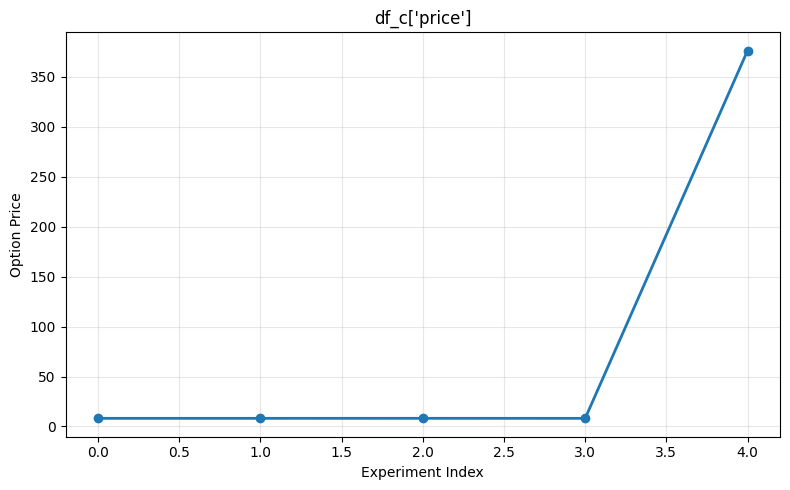

In [16]:
c_experiments = [
    {"c": 5},
    {"c": 10},
    {"c": 15},
    {"c": 20},
    {"c": 30},
]

df_c = bha.run_experiment_grid(base_params, c_experiments, "asset_clustering")

plt.figure(figsize=(8, 5))
plt.plot(df_c["price"], marker="o", linewidth=2)
plt.xlabel("Experiment Index")
plt.ylabel("Option Price")
plt.title("df_c['price']")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


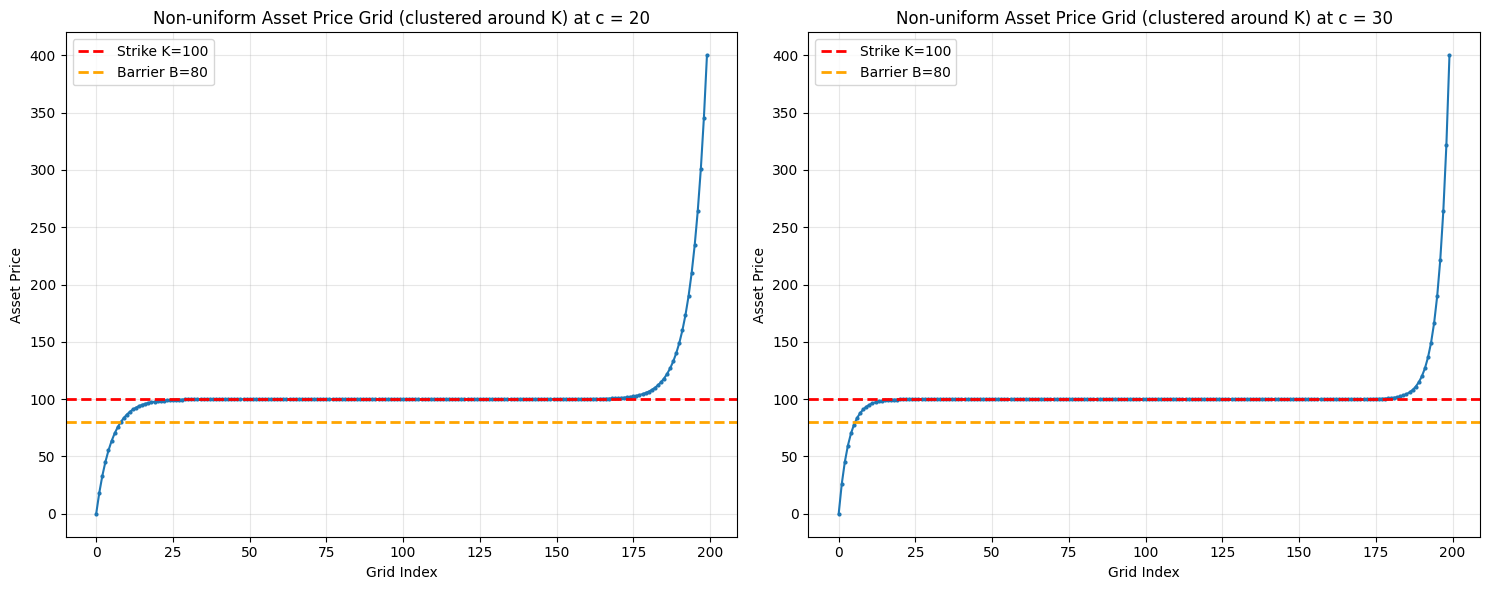

In [17]:
c1 = 20
c2 = 30
S_grid1 = create_nonuniform_asset_grid(S_min, S_max, Ns, K, c1)
S_grid2 = create_nonuniform_asset_grid(S_min, S_max, Ns, K, c2)

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Asset price grid
ax1.plot(range(len(S_grid1)), S_grid1, 'o-', markersize=2)
ax1.axhline(K, color='r', linestyle='--', linewidth=2, label=f'Strike K={K}')
ax1.axhline(B, color='orange', linestyle='--', linewidth=2, label=f'Barrier B={B}')
ax1.set_xlabel('Grid Index')
ax1.set_ylabel('Asset Price')
ax1.set_title('Non-uniform Asset Price Grid (clustered around K) at c = %d' % c1)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(len(S_grid2)), S_grid2, 'o-', markersize=2)
ax2.axhline(K, color='r', linestyle='--', linewidth=2, label=f'Strike K={K}')
ax2.axhline(B, color='orange', linestyle='--', linewidth=2, label=f'Barrier B={B}')
ax2.set_xlabel('Grid Index')
ax2.set_ylabel('Asset Price')
ax2.set_title('Non-uniform Asset Price Grid (clustered around K) at c = %d' % c2)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

[variance_clustering] run 1/3 finished in 12.266s with price=8.135611488150
[variance_clustering] run 2/3 finished in 10.557s with price=8.159858676538
[variance_clustering] run 3/3 finished in 10.379s with price=8.182992905786


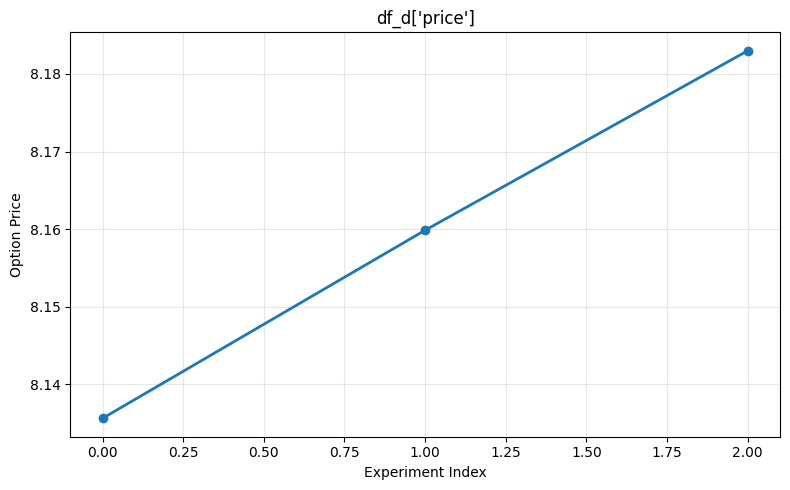

In [18]:
d_experiments = [
    {"d": 0.02},
    {"d": 0.05},
    {"d": 0.1},
]

df_d = bha.run_experiment_grid(base_params, d_experiments, "variance_clustering")

plt.figure(figsize=(8, 5))
plt.plot(df_d["price"], marker="o", linewidth=2)
plt.xlabel("Experiment Index")
plt.ylabel("Option Price")
plt.title("df_d['price']")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

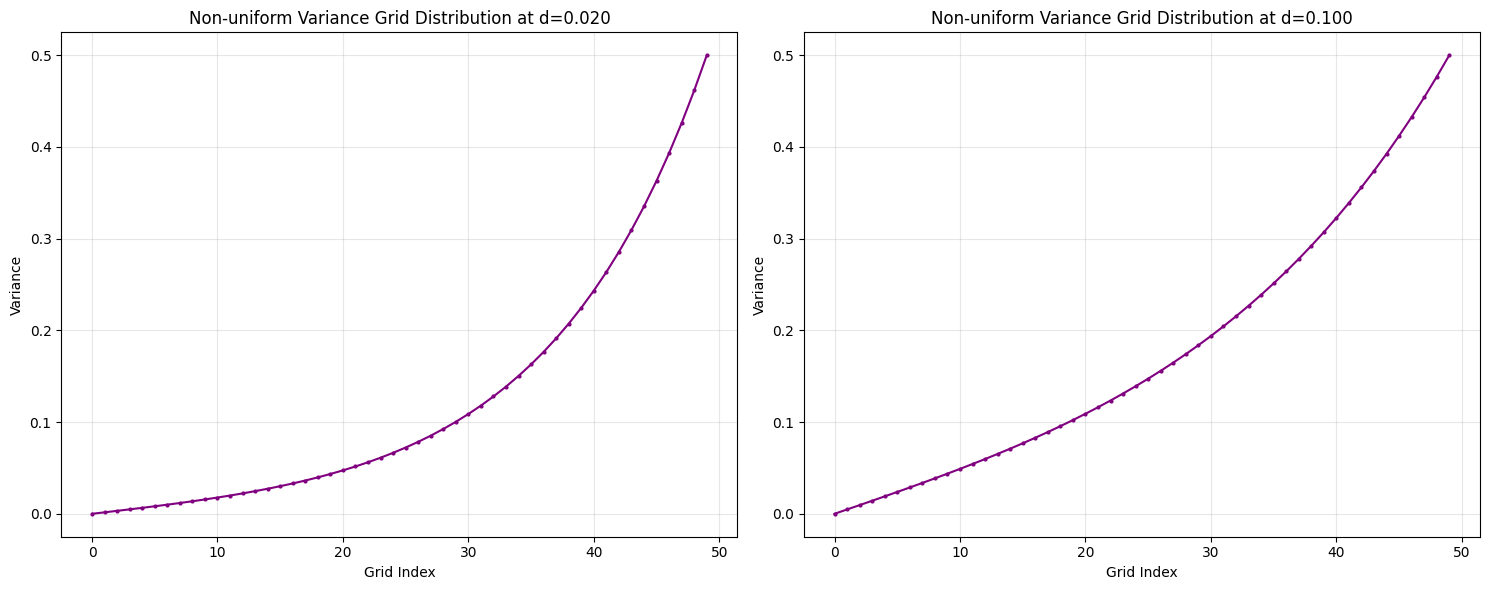

In [19]:
d1 = 0.02
d2 = 0.1
v_grid1 = create_nonuniform_variance_grid(v_min, v_max, Nv, d1)
v_grid2 = create_nonuniform_variance_grid(v_min, v_max, Nv, d2)

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Variance grid distribution
ax1.plot(range(len(v_grid1)), v_grid1, 'o-', markersize=2, color='purple')
ax1.set_xlabel('Grid Index')
ax1.set_ylabel('Variance')
ax1.set_title('Non-uniform Variance Grid Distribution at d=%.3f' % d1)
ax1.grid(True, alpha=0.3)

# Variance grid distribution
ax2.plot(range(len(v_grid2)), v_grid2, 'o-', markersize=2, color='purple')
ax2.set_xlabel('Grid Index')
ax2.set_ylabel('Variance')
ax2.set_title('Non-uniform Variance Grid Distribution at d=%.3f' % d2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

目前的ADI方案中，参数$theta_ADI$在$0.5-1.0$范围内不会影响结果的稳定性。  
$c$在30时导致的解析解错误，尽管在S的分布上不会看的明显错误。在其余正确测试范围，存在$0.3$%误差。    
$d$随着其增大，期权价格增大。$d$增大后，方差的分别越平均。但其同时也造成了$0.5$%的误差。
目前仍暂时使用最初的参数设定：
1. $c = 20$
2. $d = 0.05$
3. $thetaADI = 0.5$

### 希腊字母

方案一：通过改变输入参数获得不同条件下的期权价格，随后计算相应希腊字母

In [21]:
import copy
import numpy as np
import importlib
import barrier_heston_adi as bha

importlib.reload(bha)

def price_from_params(params):
    if isinstance(params, dict):
        params = bha.KnockOutCallParams(**params)

    result = bha.price_european_down_and_out_call_heston_adi(params)
    return result["price"]

def compute_greeks(
    base_params,
    ds = 1.0,
    dr = 1e-4,
    dT = 1/365,
    dv0 = 1e-4,
    dvol0 = 1e-3,
):
    # Base price
    p0 = copy.deepcopy(base_params)
    if p0["v0"] is None:
        p0["v0"] = p0["theta"] # Assume initial variance is long-term variance if not specified

    V0 = price_from_params(p0)

    # ----- Delta / Gamma -----
    p_up = copy.deepcopy(p0)
    p_dn = copy.deepcopy(p0)
    p_up["S0"] = p0["S0"] + ds
    p_dn["S0"] = max(1e-8, p0["S0"] - ds)

    V_up = price_from_params(p_up)
    V_dn = price_from_params(p_dn)

    delta = (V_up - V_dn) / (2 * ds)
    gamma = (V_up - 2 * V0 + V_dn) / (ds ** 2)

    # ----- Rho (interest rate sensitivity) -----
    p_r_up = copy.deepcopy(p0)
    p_r_dn = copy.deepcopy(p0)
    p_r_up["r"] = p0["r"] + dr
    p_r_dn["r"] = p0["r"] - dr

    V_r_up = price_from_params(p_r_up)
    V_r_dn = price_from_params(p_r_dn)

    rho = (V_r_up - V_r_dn) / (2 * dr)

    # ----- Theta Greek -----
    # Greek theta is usually -dV/dT
    p_T_dn = copy.deepcopy(p0)

    p_T_dn["T"] = max(1e-8, p0["T"] - dT)

    V_T_dn = price_from_params(p_T_dn)

    theta_greek = -(V0 - V_T_dn) / dT

    # ----- Vega w.r.t. initial variance v0 -----
    p_v_up = copy.deepcopy(p0)
    p_v_dn = copy.deepcopy(p0)

    p_v_up["v0"] = p0["v0"] + dv0
    p_v_dn["v0"] = max(1e-8, p0["v0"] - dv0)

    V_v_up = price_from_params(p_v_up)
    V_v_dn = price_from_params(p_v_dn)

    vega_v0 = (V_v_up - V_v_dn) / (2 * dv0)

    # ----- Vega w.r.t. initial volatility vol0 = sqrt(v0) -----
    vol0 = np.sqrt(p0["v0"])

    p_vol_up = copy.deepcopy(p0)
    p_vol_dn = copy.deepcopy(p0)

    vol_up = vol0 + dvol0
    vol_dn = max(1e-8, vol0 - dvol0)

    p_vol_up["v0"] = vol_up ** 2
    p_vol_dn["v0"] = vol_dn ** 2

    V_vol_up = price_from_params(p_vol_up)
    V_vol_dn = price_from_params(p_vol_dn)

    vega_vol0 = (V_vol_up - V_vol_dn) / (2 * dvol0)

    return {
        "price": V0,
        "delta": delta,
        "gamma": gamma,
        "rho": rho,
        "theta": theta_greek,
        "vega_v": vega_v0,
        "vega_vol": vega_vol0
    }
    
greeks = compute_greeks(
    base_params,
    ds=1.0,
    dr=1e-4,
    dT=1/365,
    dv0=1e-4,
    dvol0=1e-3,
)

for k, v in greeks.items():
    print(f"{k}: {v:.8f}")

price: 8.15985868
delta: 0.67739681
gamma: 0.02019298
rho: 58.38253092
theta: -4.18720747
vega_v: 34.28149548
vega_vol: 13.70855026


方案二，直接从PDE网格表面进行计算  
其中，Delta, Gamma, Theta, vega_on_variance可以直接从PDE的解析中获得。  
下面输出从PDE计算的网格表面直接获得的希腊字母并与前述修改输入参数获得的希腊字母进行对比。  
相关代码包装入barrier_heston.adi.py

In [37]:
import importlib
import barrier_heston_adi as bha

importlib.reload(bha)

params = bha.KnockOutCallParams(**base_params)
result = bha.price_european_down_and_out_call_heston_adi(params)

print(f"price: {result['price']:.10f}")
for k in ["delta", "gamma", "vega_v", "theta_greek"]:
    print(f"{k}: {result['greeks_pde'][k]:.10f}")


price: 8.1598586765
delta: 0.7930353411
gamma: 4009757.5759544140
vega_v: 34.2574571446
theta_greek: -3.2660264809


在目前的代码实现中：
1. $Delta$: 0.67739681 vs 0.7930353411，相差17%。
2. $Gamma$：直接从PDE网格中获取无法获得正确解，由于其为二阶导数，在目前的非均一网格中很不鲁棒。
3. $vega_v$: 34.28149548 vs 34.2574571446，相差0.07%，结果鲁棒。
4. $theta$：-4.18720747 vs -3.2660264809，相差28%。  

在PDE直接解析Greeks需要进行局部求导，可能放大噪声，而通过改变输入参数进行重算，整体结果在目前版本下更鲁棒。

### 后续考虑
1. 使用Modified Craig-Sneyd (MCS)进行求解，混合偏导项的存在使得其比目前版本的Douglas方案更可靠。
2. 对代码进行封装，提升可复用性。
3. 覆盖敲入期权、美式期权等类型的障碍期权。